In [34]:
# ==========================================
# 1. IMPORTS
# ==========================================
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import cycle # Usado para escolher cores na curva ROC

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, label_binarize # label_binarize adicionado para ROC
from sklearn.metrics import f1_score, confusion_matrix, roc_curve, auc # roc_curve e auc adicionados

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [35]:
# ==========================================
# 2. CARREGAMENTO DO DATASET
# ==========================================
print("\nCarregando os dados...")
df = pd.read_csv('BEED_Data.csv')

# Visualizar a distribuição das classes para confirmar o balanceamento original
print("Distribuição original das classes:")
print(df['y'].value_counts())

# Separar features (X) e rótulos (y)
# X1 a X16 são as características do EEG
X = df.drop('y', axis=1).values
y = df['y'].values


Carregando os dados...
Distribuição original das classes:
y
0    2000
1    2000
2    2000
3    2000
Name: count, dtype: int64


In [36]:
# ==========================================
# 3. PRÉ-PROCESSAMENTO DOS DADOS
# ==========================================
# 3.1 Particionamento Estratificado (Garante o Balanceamento)
# Divisão: 70% Treino, 15% Validação, 15% Teste
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=(0.15/0.85), random_state=42, stratify=y_temp
)

# 3.2 Padronização (Z-score normalization)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# 3.3 Conversão para Tensores do PyTorch
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)

X_val_t = torch.tensor(X_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.long)

X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.long)

# 3.4 Criação dos DataLoaders (Batching)
batch_size = 64
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=batch_size, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=batch_size, shuffle=False)
test_loader = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=batch_size, shuffle=False)

In [37]:
# ==========================================
# 4. DEFINIÇÃO DA ARQUITETURA DO MODELO
# ==========================================
class MLP(nn.Module):
    def __init__(self, input_size, num_classes):
        super(MLP, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.ReLU(),
            nn.Dropout(0.3), # Evitar Overfitting
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, num_classes)
            # Sem camada Softmax aqui pois utilizaremos a função CrossEntropyLoss 
            # que já combina LogSoftmax + NLLLoss internamente.
        )

    def forward(self, x):
        return self.network(x)

# Instanciando o modelo (16 features de entrada, 4 classes de saída)
input_dim = X_train.shape[1]
num_classes = len(np.unique(y))
model = MLP(input_size=input_dim, num_classes=num_classes).to(device)

In [38]:
# ==========================================
# 5. TREINAMENTO DO MODELO
# ==========================================
train_loss_history = []
val_loss_history = []

epochs = 50
best_val_loss = float('inf')

print("Iniciando o Treinamento...")
for epoch in range(epochs):
    # Treino
    model.train()
    train_loss = 0.0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * inputs.size(0)
    train_loss /= len(train_loader.dataset)
    
    # Validação
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * inputs.size(0)
    val_loss /= len(val_loader.dataset)
    
    # -> MODIFICAÇÃO: Salvar os valores na lista para o gráfico de generalização
    train_loss_history.append(train_loss)
    val_loss_history.append(val_loss)
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'best_model_checkpoint.pth')

Iniciando o Treinamento...


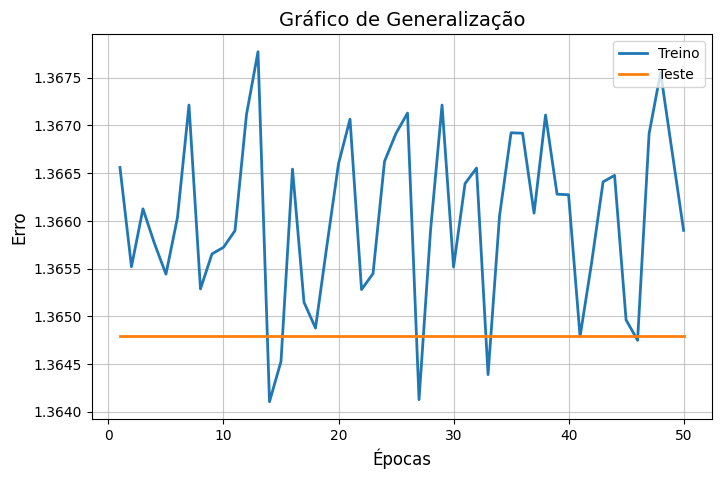

In [39]:
# ==========================================
# GRÁFICO DE GENERALIZAÇÃO
# ==========================================
plt.figure(figsize=(8, 5))

# Plotando as linhas com as cores e rótulos exatos da sua imagem
plt.plot(range(1, epochs+1), train_loss_history, label='Treino', color='tab:blue', linewidth=2)
plt.plot(range(1, epochs+1), val_loss_history, label='Teste', color='tab:orange', linewidth=2)

# Ajustando os textos dos eixos e título para bater com a referência
plt.xlabel('Épocas', fontsize=12)
plt.ylabel('Erro', fontsize=12)
plt.title('Gráfico de Generalização', fontsize=14)

# Colocando a legenda no canto superior direito
plt.legend(loc='upper right')

# Adicionando a grade de fundo
plt.grid(True, linestyle='-', alpha=0.7)

# Exibe o gráfico
plt.show()

F1-Score (Macro) no Teste: 0.2371


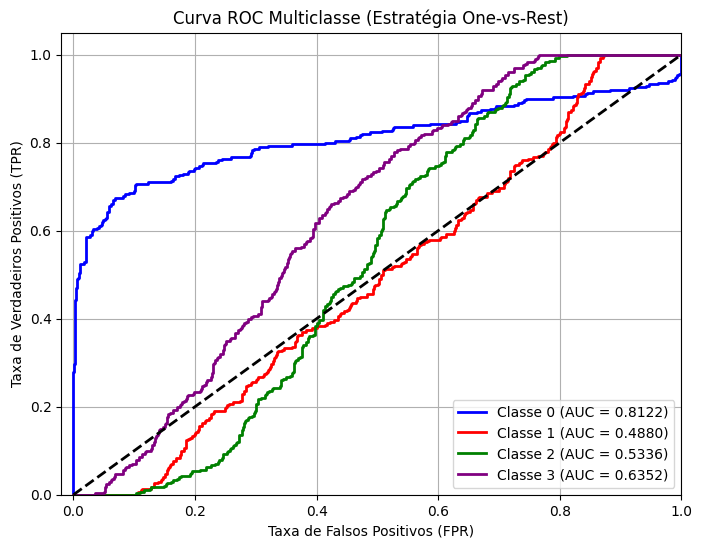

In [40]:
# ==========================================
# 6. AVALIAÇÃO DO MODELO
# ==========================================
model.load_state_dict(torch.load('best_model_checkpoint.pth'))
model.eval()

y_true = []
y_pred = []
y_probs = [] # -> MODIFICAÇÃO: Lista para guardar probabilidades (necessário para a ROC)

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        
        # Extrair a probabilidade (necessário para AUC/ROC)
        probabilities = torch.softmax(outputs, dim=1)
        _, predicted = torch.max(outputs.data, 1)
        
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())
        y_probs.extend(probabilities.cpu().numpy())

y_true = np.array(y_true)
y_probs = np.array(y_probs)

f1 = f1_score(y_true, y_pred, average='macro')
print(f"F1-Score (Macro) no Teste: {f1:.4f}")

# -> MODIFICAÇÃO: Cálculo e Plot da Curva ROC Multiclasse (One-vs-Rest)
# Binarizamos o 'y_true' para que vire [1, 0, 0, 0], [0, 1, 0, 0] etc.
y_true_bin = label_binarize(y_true, classes=[0, 1, 2, 3])
n_classes = y_true_bin.shape[1]

fpr = dict()
tpr = dict()
roc_auc = dict()

# Calcula a curva ROC e o valor AUC para cada classe separadamente
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(8, 6))
colors = cycle(['blue', 'red', 'green', 'purple'])
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'Classe {i} (AUC = {roc_auc[i]:.4f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2) # Linha de classificação aleatória
plt.xlim([-0.02, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taxa de Falsos Positivos (FPR)')
plt.ylabel('Taxa de Verdadeiros Positivos (TPR)')
plt.title('Curva ROC Multiclasse (Estratégia One-vs-Rest)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show() # Exibe o gráfico 2

In [41]:
# ==========================================
# 7. SALVAMENTO DO MODELO
# ==========================================
caminho_modelo = 'mlp_beed_final.pth'
torch.save(model.state_dict(), caminho_modelo)
print(f"\nModelo final treinado e salvo com sucesso em: {caminho_modelo}")


Modelo final treinado e salvo com sucesso em: mlp_beed_final.pth
